# LangGraph Practice

In this notebook, we will build a basic agent using the **LangGraph** framework. We will cover:
1.  Creating a basic agent.
2.  Using standard tools.
3.  Simulating an **MCP (Model Context Protocol)** tool.
4.  Observing the agent's execution steps.

We will use OpenAI's **GPT-4.1-mini** model.

## 1. Prerequisites and Installation
First, let's install the necessary libraries.

In [16]:
%pip install -qU langgraph langchain langchain-openai langchain-core pydantic

Note: you may need to restart the kernel to use updated packages.


## 2. Setup Environment Variables
We need to set up the `OPENAI_API_KEY` and `OPENAI_BASE_URL` to use the GPT-4.1-mini model.

In [17]:
import getpass
import os
from dotenv import load_dotenv

load_dotenv()
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key: ")

if "OPENAI_BASE_URL" not in os.environ:
    os.environ["OPENAI_BASE_URL"] = getpass.getpass("Enter your OpenAI Base URL: ")

### 2.1 Setup Observability (LangSmith)
To visualize the agent's steps, we will use LangSmith. You can sign up for a free account at [smith.langchain.com](https://smith.langchain.com/).

In [18]:
os.environ["LANGCHAIN_TRACING_V2"] = "true"

if "LANGSMITH_API_KEY" not in os.environ:
    os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter your LangSmith API Key: ")

## 3. Initialize the OpenAI Model
We will use `ChatOpenAI` with the `gpt-4.1-mini` model.

In [19]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
    base_url=os.environ["OPENAI_BASE_URL"]
)

## 4. Define a Basic Calculator Tool
We'll create a simple multiplication tool.

In [20]:
from langchain_core.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two integers."""
    return a * b

print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Multiplies two integers.
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


## 5. Define an MCP Tool (Mock Weather Service)
The **Model Context Protocol (MCP)** is a standard for connecting AI models to external data and tools.
Here, we will simulate an MCP tool that fetches weather data. In a real scenario, this would connect to an MCP server.

In [21]:
@tool
def get_weather_mcp(city: str) -> str:
    """
    Fetches weather data for a given city.
    This tool simulates an MCP tool interaction.
    """
    # In a real MCP implementation, this would make a request to an MCP server.
    # client.call_tool("weather_server", "get_weather", {"city": city})

    mock_data = {
        "London": "Rainy, 15°C",
        "New York": "Sunny, 22°C",
        "Tokyo": "Cloudy, 18°C"
    }
    return mock_data.get(city, "Weather data not available for this city.")

tools = [multiply, get_weather_mcp]
llm_with_tools = llm.bind_tools(tools)

## 6. Define the Agent State
We need a state to hold the conversation history.

In [22]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

## 7. Create Nodes
We define the **Agent Node** (which calls the model) and the **Tool Node** (which executes tools).

In [23]:
from langgraph.prebuilt import ToolNode

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

tool_node = ToolNode(tools)

## 8. Build the LangGraph Workflow
We connect the nodes and define the logic.

In [24]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", tool_node)

graph_builder.add_edge(START, "chatbot")

def route_tools(state: State):
    if state["messages"][-1].tool_calls:
        return "tools"
    return END

graph_builder.add_conditional_edges("chatbot", route_tools, {"tools": "tools", END: END})
graph_builder.add_edge("tools", "chatbot")

graph = graph_builder.compile()

## 9. Visualize the Graph

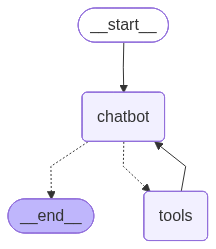

In [25]:
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Could not draw graph (requires graphviz/mermaid support).")
    graph.get_graph().print_ascii()

## 10. Run the Agent with Observability
We can now run the agent. LangGraph provides built-in observability by allowing us to stream the steps.

In [26]:
user_input = "What is 5 times 8? Also, what is the weather in London?"

print(f"User: {user_input}\n")
print("Running agent with LangSmith tracing...\n")

events = graph.stream(
    {"messages": [("user", user_input)]},
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

User: What is 5 times 8? Also, what is the weather in London?

Running agent with LangSmith tracing...

================================ Human Message =================================

What is 5 times 8? Also, what is the weather in London?
================================== Ai Message ==================================
Tool Calls:
  multiply (call_iV74e1YJeUWcOopfQ9tpjeOP)
 Call ID: call_iV74e1YJeUWcOopfQ9tpjeOP
  Args:
    a: 5
    b: 8
  get_weather_mcp (call_pz16epONPVXc4H3iCF19CAVp)
 Call ID: call_pz16epONPVXc4H3iCF19CAVp
  Args:
    city: London
================================= Tool Message =================================
Name: get_weather_mcp

Rainy, 15°C
================================== Ai Message ==================================

5 times 8 is 40. The weather in London is rainy with a temperature of 15°C.


## 11. Observe the run in Langsmith

## 12. Challenge: Build a Travel Assistant

Now it's your turn! Apply what you've learned to build a **Travel Assistant Agent**.

**Requirements:**
1.  **Create a Tool**: `calculate_distance(origin: str, destination: str) -> int`. Return a mock distance (e.g., based on the length of the city names or just a random number).
2.  **Create an MCP Tool**: `get_hotel_recommendations_mcp(city: str) -> str`. Return a mock list of hotels for the given city.
3.  **Build the Graph**: Create a new `StateGraph` with a new agent node and tool node.
4.  **Run**: Ask the agent: *"I want to travel from New York to Paris. How far is it and can you recommend a hotel?"*
5.  **Observe**: Use the streaming output to verify the tools are called correctly.

In [27]:
# TODO: Implement your Travel Assistant here

# 1. Define tools
@tool
def calculate_distance(origin: str, destination: str) -> int:
    """Calculates the distance between two cities in km."""
    # Mock distances based on city pairs
    distances = {
        ("New York", "Paris"): 5837,
        ("Paris", "New York"): 5837,
        ("London", "Tokyo"): 9570,
        ("Tokyo", "London"): 9570,
        ("New York", "London"): 5570,
        ("London", "New York"): 5570,
    }
    key = (origin, destination)
    return distances.get(key, abs(len(origin) - len(destination)) * 1000 + 5000)

@tool
def get_hotel_recommendations_mcp(city: str) -> str:
    """Fetches hotel recommendations for a city."""
    recommendations = {
        "Paris": "The Ritz Paris, Hotel de Crillon, Mandarin Oriental Paris",
        "New York": "The Plaza Hotel, Four Seasons New York, The Peninsula New York",
        "London": "Savoy London, The Goring, Claridge's",
        "Tokyo": "Hotel Okura Tokyo, Aman Tokyo, Peninsula Tokyo"
    }
    hotels = recommendations.get(city, "No recommendations available for this city.")
    return f"Top hotels in {city}: {hotels}"

# 2. Bind tools to LLM
travel_tools = [calculate_distance, get_hotel_recommendations_mcp]
llm_travel = llm.bind_tools(travel_tools)

# 3. Define Agent Node
def travel_agent(state: State):
    return {"messages": [llm_travel.invoke(state["messages"])]}

# 4. Build Graph
travel_graph_builder = StateGraph(State)
travel_graph_builder.add_node("agent", travel_agent)
travel_graph_builder.add_node("tools", ToolNode(travel_tools))

travel_graph_builder.add_edge(START, "agent")

def route_travel_tools(state: State):
    if state["messages"][-1].tool_calls:
        return "tools"
    return END

travel_graph_builder.add_conditional_edges("agent", route_travel_tools, {"tools": "tools", END: END})
travel_graph_builder.add_edge("tools", "agent")

travel_graph = travel_graph_builder.compile()

# 5. Run and Observe
user_input = "I want to travel from New York to Paris. How far is it and can you recommend a hotel?"

events = travel_graph.stream(
    {"messages": [("user", user_input)]},
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I want to travel from New York to Paris. How far is it and can you recommend a hotel?
================================== Ai Message ==================================
Tool Calls:
  calculate_distance (call_Zevr4jOjej6oUc84HkeEEsXL)
 Call ID: call_Zevr4jOjej6oUc84HkeEEsXL
  Args:
    origin: New York
    destination: Paris
  get_hotel_recommendations_mcp (call_ymKWV02k11BQicxvuR87gR59)
 Call ID: call_ymKWV02k11BQicxvuR87gR59
  Args:
    city: Paris
================================= Tool Message =================================
Name: get_hotel_recommendations_mcp

Top hotels in Paris: The Ritz Paris, Hotel de Crillon, Mandarin Oriental Paris
================================== Ai Message ==================================

The distance from New York to Paris is approximately 5837 km. As for hotels in Paris, some top recommendations are The Ritz Paris, Hotel de Crillon, and Mandarin Oriental Paris. Would you

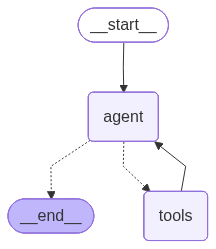

In [28]:

# Visualize the Travel Agent Graph
try:
    from IPython.display import Image, display
    display(Image(travel_graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Could not draw graph (requires graphviz/mermaid support).")
    travel_graph.get_graph().print_ascii()
